In [1]:
import pandas as pd

df = pd.read_csv('/content/train.csv')
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [4]:
mapping = {
    'Not Placed' : 0,
    'Placed' : 1
}

df['Placement_Status'] = df['Placement_Status'].map(mapping)
df.head()

,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,0
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,0
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,0
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,1
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,1


In [5]:
df = df.drop(columns = ['Student_ID', 'Age', 'Gender', 'Degree', 'Branch'])
df.head()

,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,6.29,0,3,4,6,51,5,1,3,0
1,6.05,1,4,6,8,59,8,2,1,0
2,7.22,1,4,6,6,58,6,2,2,0
3,7.78,2,4,6,6,90,4,2,0,1
4,7.63,1,4,6,5,79,6,2,0,1


In [6]:
df.shape

(45000, 10)

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Placement_Status'])
y = df['Placement_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [30]:
from sklearn.linear_model import Perceptron

model_10_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.1)
model_20_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.2)
model_30_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.3)
model_40_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.4)
model_50_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.5)
model_60_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.6)
model_70_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.7)
model_80_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.8)
model_90_percent = Perceptron(penalty = 'elasticnet', alpha = 0.0001, l1_ratio=0.9)

models = [model_10_percent, model_20_percent, model_30_percent, model_40_percent, model_50_percent, model_60_percent, model_70_percent, model_80_percent, model_90_percent]

for model in models:
  model.fit(X_train, y_train)

In [31]:
y_pred_list = []

for model in models:
  y_pred = model.predict(X_test)
  y_pred_list.append(y_pred)

In [32]:
from sklearn.metrics import f1_score

f1_scores = []

for y_pred in y_pred_list:
  f1 = f1_score(y_test, y_pred)
  f1_scores.append(f1)

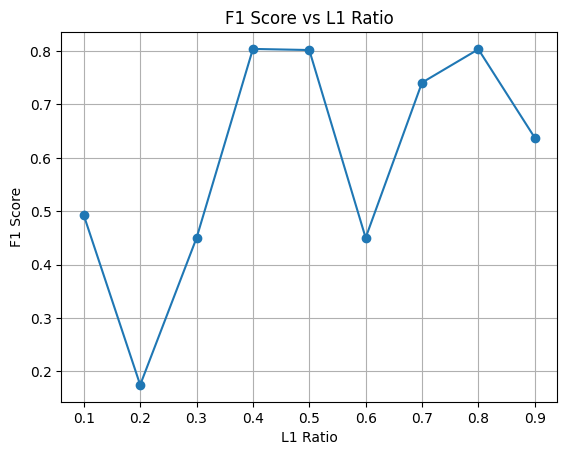

In [33]:
import matplotlib.pyplot as plt

l1_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

plt.plot(l1_ratios, f1_scores, marker='o')
plt.xlabel('L1 Ratio')
plt.ylabel('F1 Score')
plt.title('F1 Score vs L1 Ratio')
plt.grid(True)
plt.show()